In [30]:
import ultralytics
from ultralytics import YOLO

In [31]:
import cv2 
import numpy as np 
import matplotlib.pyplot as plt 
from PIL import Image 

import warnings 
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')  # Suppress Matplotlib warnings

In [32]:
# !pip install ttach

In [33]:
plt.rcParams["figure.figsize"] = [3.0, 3.0]

# Just import these 2 modules

In [34]:
from yolo_cam.eigen_cam import EigenCAM
from yolo_cam.utils.image import show_cam_on_image, scale_cam_image

# YOLO 26 Classification Model

In [61]:
img = cv2.imread('images/lepidoptera.jpg')
img = cv2.resize(img, (640, 640))
rgb_img = img.copy()
img = np.float32(img) / 255

In [62]:
model = YOLO("./runs/classify/train3/weights/best.pt") 
model = model.cpu()

In [63]:
target_layers = [model.model.model[-3]]

### You may get an inaccurate output at first (if it's running on GPU)

0: 640x640 Lepidoptera 0.95, Hymenoptera 0.05, Coleoptera 0.00, 192.4ms
Speed: 17.8ms preprocess, 192.4ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)


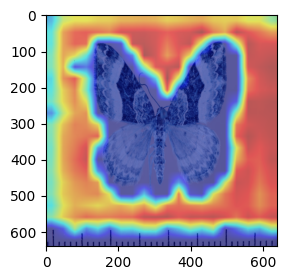

In [64]:
cam = EigenCAM(model, target_layers, task='cls')
grayscale_cam = cam(rgb_img)[0, :, :]
cam_image = show_cam_on_image(img, grayscale_cam, use_rgb=True)
plt.imshow(cam_image)
plt.show()

### Simply Re-running the cell will do the trick


0: 640x640 Lepidoptera 0.95, Hymenoptera 0.05, Coleoptera 0.00, 139.1ms
Speed: 18.6ms preprocess, 139.1ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)


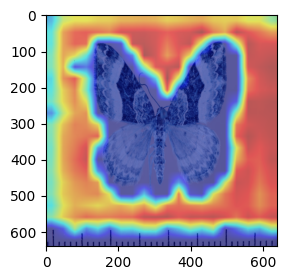

In [65]:
cam = EigenCAM(model, target_layers, task='cls')
grayscale_cam = cam(rgb_img)[0, :, :]
cam_image = show_cam_on_image(img, grayscale_cam, use_rgb=True)
plt.imshow(cam_image)
plt.show()

# YOLO 26 Object Detection Model

In [66]:
model_od = YOLO('yolo26n.pt')
model_od = model_od.cpu()
target_layers_od = [model_od.model.model[-2]]


0: 640x640 (no detections), 184.0ms
Speed: 5.7ms preprocess, 184.0ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)


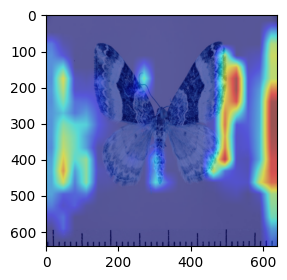

In [67]:
cam = EigenCAM(model_od, target_layers_od, task='od')
grayscale_cam = cam(rgb_img)[0, :, :]
cam_image = show_cam_on_image(img, grayscale_cam, use_rgb=True)
plt.imshow(cam_image)
plt.show()

# YOLO 26 Segmentation Model

In [68]:
model_seg = YOLO('yolo26n-seg.pt')
model_seg = model_seg.cpu()
target_layers_seg = [model_seg.model.model[-3]]


0: 640x640 (no detections), 221.1ms
Speed: 8.1ms preprocess, 221.1ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 640)


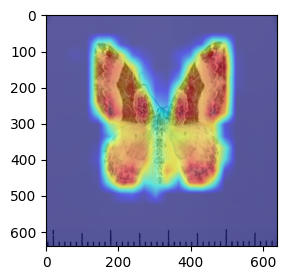

In [69]:
cam = EigenCAM(model_seg, target_layers_seg, task='seg')
grayscale_cam = cam(rgb_img)[0, :, :]
cam_image = show_cam_on_image(img, grayscale_cam, use_rgb=True)
plt.imshow(cam_image)
plt.show()